# Basic stacking ensemble - linear stage 2

Use a basic stacking ensemble built with SciKit-Learn's `StackingClassifier()`.

**Notes:**

Basic ensemble with balanced class weighting, probability stacking and no pass through gives almost exactly same leaderboard results at optimized gradient boosting model.

## 1. Notebook setup

### 1.1. Imports

In [1]:
# Standard library
import pickle

# Third party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

# Internal
from helper_functions.data_preprocessing import encode_label

### 1.2. Configuration

In [2]:
RUN_PERFORMANCE_ESTIMATION = True

# Input artifacts (outputs from notebook 03)
CV_FOLD_DATASET         = '../data/tmp/03-preprocessed-cv-folds.pkl'
WINNING_HYPERPARAMETERS = '../data/results/03-winning-hyperparameters.pkl'
FINAL_TRAINING_DATA     = '../data/tmp/03-preprocessed-train-data.csv'
FINAL_TESTING_DATA      = '../data/tmp/03-preprocessed-test-data.csv'

# Outputs
CROSS_VALIDATION_SCORES = '../data/results/05-cross-val-scores.pkl'
FINAL_SUBMISSION_FILE   = '../data/submission.csv'

## 2. Load artifacts from notebook 03

In [3]:
# CV folds - already preprocessed fold-by-fold (no leakage)
with open(CV_FOLD_DATASET, 'rb') as f:
    cv_folds = pd.read_pickle(f)

CV_FOLDS = len(cv_folds)

# Optimized model hyperparameters
with open(WINNING_HYPERPARAMETERS, 'rb') as f:
    winning_hgb_params = pickle.load(f)

# Full preprocessed datasets for final training / submission
train_df = pd.read_csv(FINAL_TRAINING_DATA)
test_df = pd.read_csv(FINAL_TESTING_DATA)

# Label encoder for submission decoding
raw_train = pd.read_csv(
    'https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/'
    'refs/heads/main/data/student-health-risk-train.csv'
)
_, label_encoder = encode_label(raw_train['health_condition'])

print(f'Loaded {CV_FOLDS} CV folds')
print(f'Preprocessed training data: {train_df.shape}')
print(f'Preprocessed test data:     {test_df.shape}')
print(f'Winning hyperparameters:     {winning_hgb_params}')

Loaded 10 CV folds
Preprocessed training data: (690088, 33)
Preprocessed test data:     (295753, 33)
Winning hyperparameters:     {'max_depth': 7, 'learning_rate': np.float64(0.05), 'max_iter': 200, 'max_features': np.float64(0.8)}


## 3. Stacking model

In [4]:
def build_stacking_model(random_state=315):
    '''Builds and returns SKLearn stacking model'''

    base_estimators = [
        (
            'hgb',
            HistGradientBoostingClassifier(
                **winning_hgb_params,
                class_weight='balanced',
                random_state=random_state,
            )
        ),
        (
            'rf',
            RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                class_weight='balanced_subsample',
                random_state=random_state,
                n_jobs=5,
            )
        ),
        (
            'et',
            ExtraTreesClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                class_weight='balanced_subsample',
                random_state=random_state,
                n_jobs=5,
            )
        )
    ]

    meta_learner = LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=random_state
    )

    model = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        stack_method='predict_proba',
        passthrough=True,
        cv=3,
        n_jobs=5
    )

    return model

## 4. Performance estimation

### 4.1. Cross-validation

In [5]:
%%time

if RUN_PERFORMANCE_ESTIMATION:

    # Train and evaluate stacking model on each fold
    fold_scores = []

    for i, fold in enumerate(cv_folds):
        print(f'Fold {i + 1} of {CV_FOLDS}...', end='\r')
        model = build_stacking_model()
        model.fit(fold['x_train'], fold['y_train'])

        y_pred = model.predict(fold['x_validation'])
        score = balanced_accuracy_score(fold['y_validation'], y_pred)
        fold_scores.append(score)

    with open(CROSS_VALIDATION_SCORES, 'wb') as f:
        pickle.dump(fold_scores, f)

    print()

else:

    with open(CROSS_VALIDATION_SCORES, 'rb') as f:
        fold_scores = pickle.load(f)

ci_lower, ci_upper = np.percentile(fold_scores, [2.5, 97.5])

print(f"Mean balanced accuracy score: {sum(fold_scores) / len(fold_scores):.4f}")
print(f"Median balanced accuracy score: {np.median(fold_scores):.4f}")
print(f"95% confidence interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

print()

/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Mean balanced accuracy score: 0.9487
Median balanced accuracy score: 0.9490
95% confidence interval: [0.9471, 0.9501]

CPU times: user 1d 9h 32min 21s, sys: 1min 52s, total: 1d 9h 34min 14s
Wall time: 4h 59min 49s


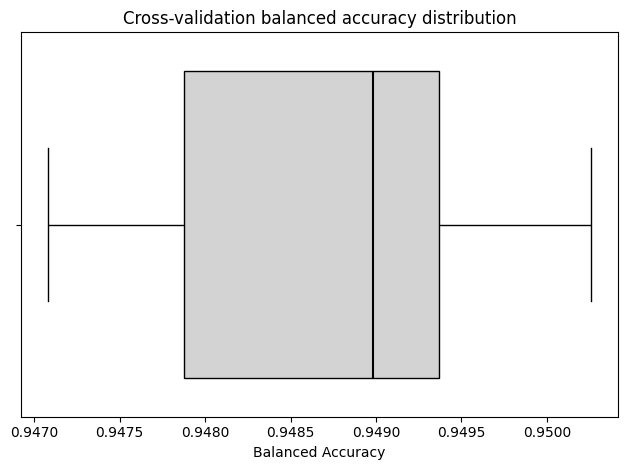

In [6]:
plt.title('Cross-validation balanced accuracy distribution')
sns.boxplot(
    x=fold_scores,
    color='lightgray',
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)
plt.xlabel('Balanced Accuracy')
plt.tight_layout()
plt.show()

## 5. Final model and submission

Fit the final stacking ensemble on the full preprocessed training data and generate a Kaggle submission file.

In [7]:
%%time

final_model = build_stacking_model(random_state=315)
final_model.fit(train_df.drop('health_condition', axis=1), train_df['health_condition'])

print('Final stacking model trained successfully')

y_pred = final_model.predict(test_df.drop('id', axis=1))
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'health_condition': label_encoder.inverse_transform(y_pred)
})

submission_df.to_csv(FINAL_SUBMISSION_FILE, index=False)
print(f'Submission saved to {FINAL_SUBMISSION_FILE}')
print(submission_df['health_condition'].value_counts())
submission_df.head()
print()

/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Final stacking model trained successfully
Submission saved to ../data/submission.csv
health_condition
at-risk      241075
unhealthy     33067
fit           21611
Name: count, dtype: int64

CPU times: user 3h 28min 12s, sys: 15.1 s, total: 3h 28min 27s
Wall time: 32min 52s
